In [20]:
#Setup and Loading Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

In [21]:
url = 'https://github.com/srishti-gururaj/Shopper-Spectrum/raw/refs/heads/main/online_retail.zip.zip'

In [22]:
df = pd.read_csv(url, compression='zip', encoding='unicode_escape')

In [23]:
print("Data loaded successfully!")
print(f"Initial Shape: {df.shape}")

Data loaded successfully!
Initial Shape: (541909, 8)


In [24]:
# Show the first 5 rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [25]:
# Dataset Understanding & Duplicates
print("--- Dataset Info ---")
df.info()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [26]:
print("\n--- Missing Values Check ---")
print(df.isnull().sum())


--- Missing Values Check ---
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [28]:
# Checking and removing duplicates
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed successfully.")

print(f"Shape after removing duplicates: {df.shape}")


Number of duplicate rows found: 0
Shape after removing duplicates: (536641, 8)


In [29]:
# Check size before cleaning
print(f"Size of our data BEFORE cleaning: {df.shape[0]} rows")

Size of our data BEFORE cleaning: 536641 rows


In [30]:
# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

In [31]:
# Exclude cancelled invoices (InvoiceNo starting with 'C')
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df = df[~df['InvoiceNo'].str.startswith('C')]

In [32]:
# Remove negative or zero quantities and prices
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [33]:
# Check size after cleaning
print(f"Size of our data AFTER cleaning: {df.shape[0]} rows")

Size of our data AFTER cleaning: 392692 rows


In [34]:
# Show the clean data
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [43]:
# Feature Engineering - Calculating RFM
# CREATE THE TOTAL PRICE COLUMN
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [44]:
# Convert InvoiceDate to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [45]:
# Create a snapshot date (1 day after the latest transaction)
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

In [47]:
# Calculate R, F, M for each customer
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'TotalPrice': 'sum'                                      # Monetary
}).reset_index()


In [48]:
# Rename columns so they match your PPT
rfm.rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'TotalPrice': 'Monetary'}, inplace=True)

print("RFM Table created successfully!")
rfm.head()

RFM Table created successfully!


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


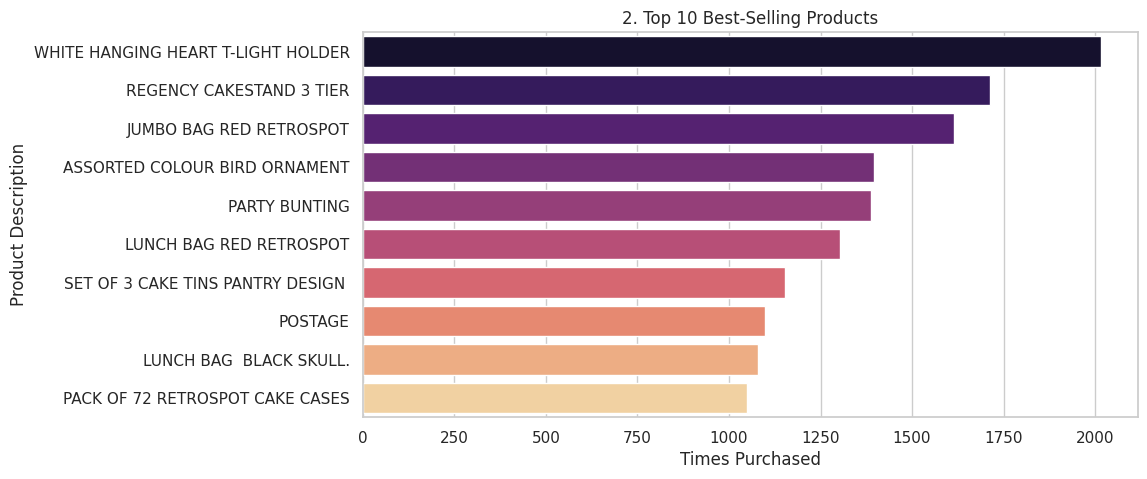

In [68]:
# 1. Horizontal Bar Plot
plt.figure(figsize=(10, 5))

top_products = df['Description'].value_counts().head(10)
sns.barplot(x=top_products.values, y=top_products.index, palette='magma')

plt.title('2. Top 10 Best-Selling Products')
plt.xlabel('Times Purchased')
plt.ylabel('Product Description')
plt.show()

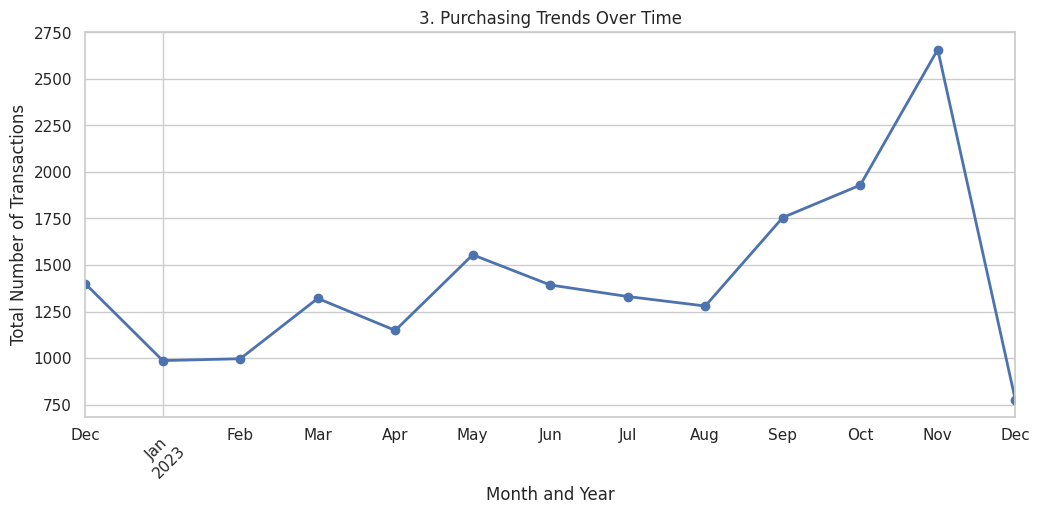

In [69]:
# 2. Line Chart
plt.figure(figsize=(12, 5))
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('YearMonth')['InvoiceNo'].nunique()

monthly_sales.plot(kind='line', marker='o', color='b', linewidth=2)

plt.title('3. Purchasing Trends Over Time')
plt.xlabel('Month and Year')
plt.ylabel('Total Number of Transactions')
plt.xticks(rotation=45)
plt.show()

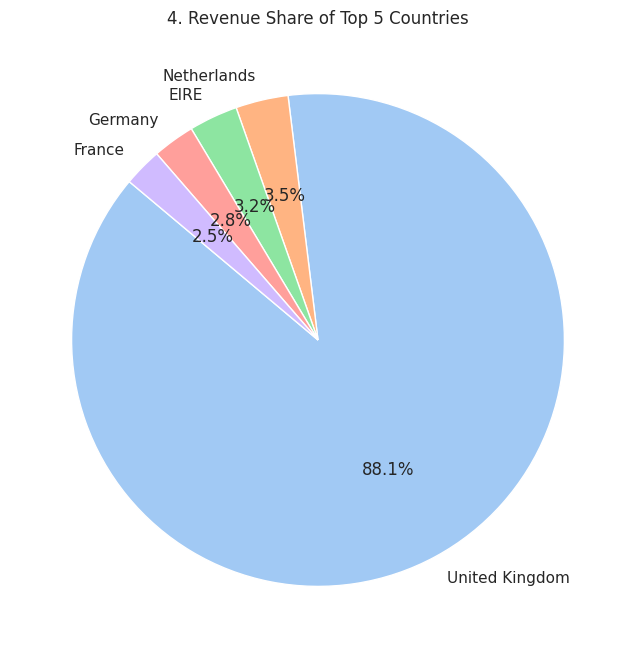

In [70]:
# 3. Pie Chart
plt.figure(figsize=(8, 8))

top_countries_revenue = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(5)
plt.pie(top_countries_revenue, labels=top_countries_revenue.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))

plt.title('4. Revenue Share of Top 5 Countries')
plt.show()

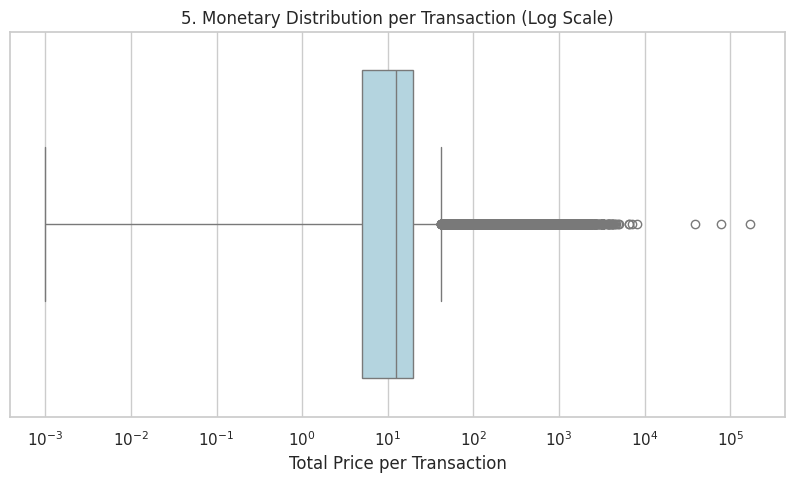

In [71]:
# 4. Box Plot
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['TotalPrice'], color='lightblue')
plt.xscale('log')

plt.title('5. Monetary Distribution per Transaction (Log Scale)')
plt.xlabel('Total Price per Transaction')
plt.show()

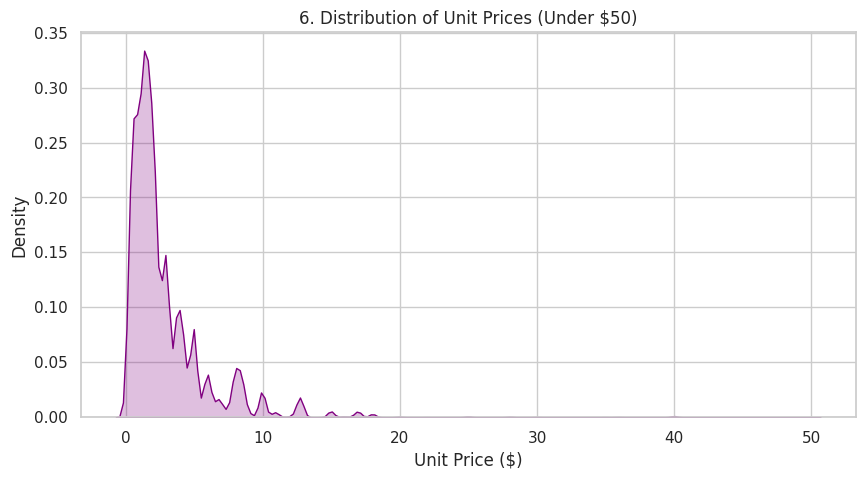

In [72]:
# 5. Density Plot (KDE)
plt.figure(figsize=(10, 5))
sns.kdeplot(df[df['UnitPrice'] < 50]['UnitPrice'], fill=True, color='purple')

plt.title('6. Distribution of Unit Prices (Under $50)')
plt.xlabel('Unit Price ($)')
plt.show()

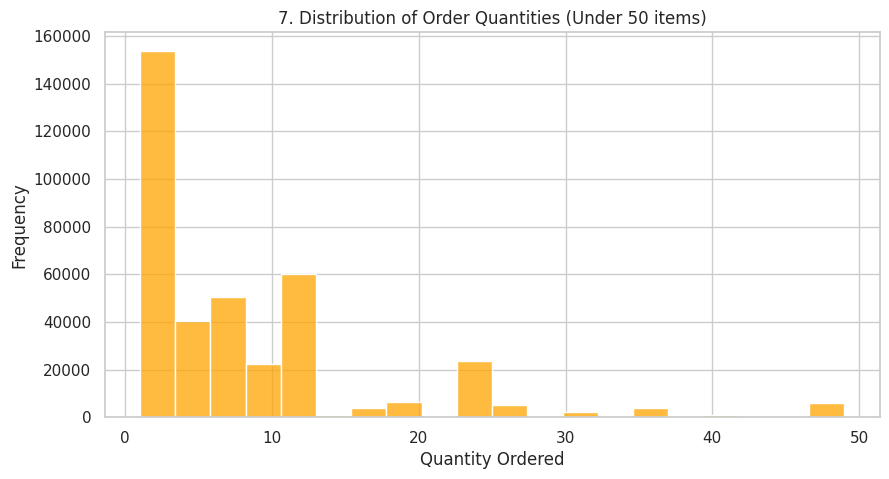

In [73]:
# 6. Histogram
plt.figure(figsize=(10, 5))
sns.histplot(df[df['Quantity'] < 50]['Quantity'], bins=20, kde=False, color='orange')

plt.title('7. Distribution of Order Quantities (Under 50 items)')
plt.xlabel('Quantity Ordered')
plt.ylabel('Frequency')
plt.show()

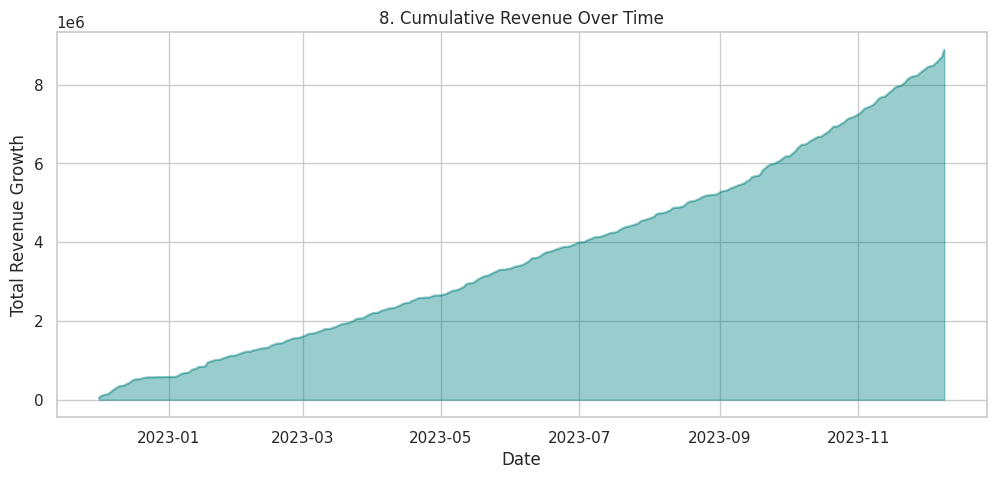

In [74]:
# 7. Area Chart
plt.figure(figsize=(12, 5))

daily_revenue = df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum().cumsum()
daily_revenue.plot(kind='area', color='teal', alpha=0.4)

plt.title('8. Cumulative Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Total Revenue Growth')
plt.show()

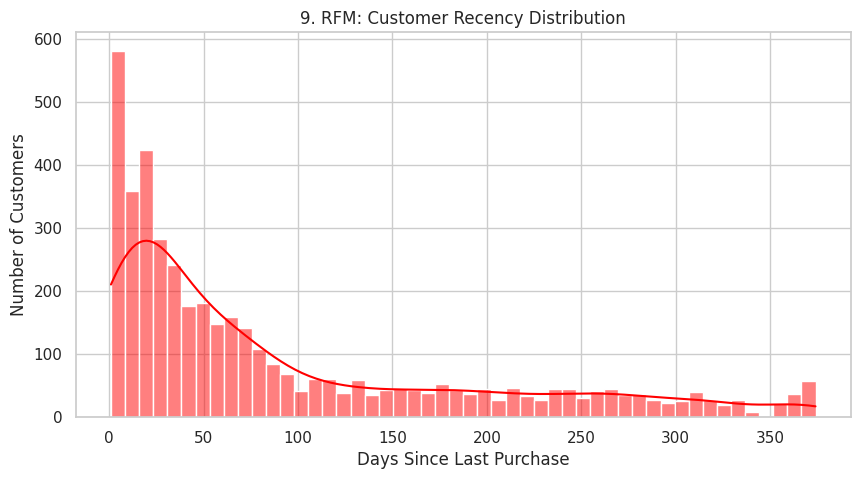

In [75]:
# 8. Histogram - Recency Distribution (RFM)
plt.figure(figsize=(10, 5))

sns.histplot(rfm['Recency'], bins=50, kde=True, color='red')

plt.title('9. RFM: Customer Recency Distribution')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Number of Customers')
plt.show()

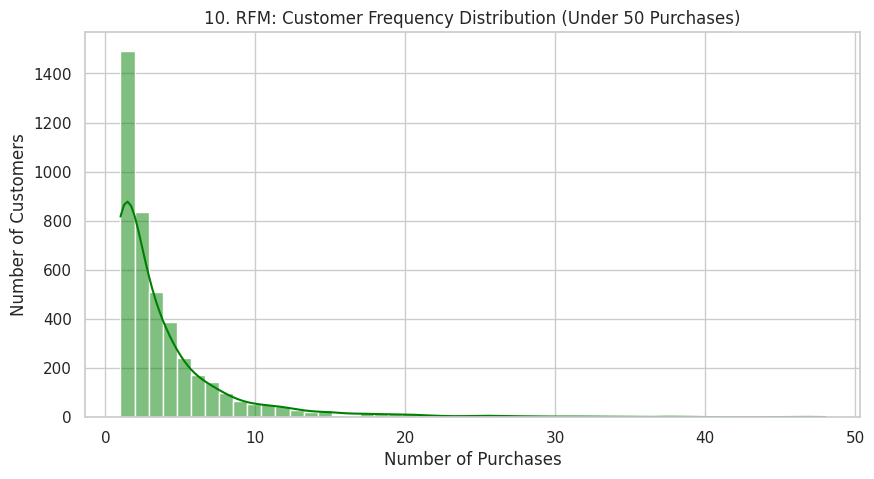

In [76]:
# 9. Histogram - Frequency Distribution (RFM)
plt.figure(figsize=(10, 5))
sns.histplot(rfm[rfm['Frequency'] < 50]['Frequency'], bins=50, kde=True, color='green')

plt.title('10. RFM: Customer Frequency Distribution (Under 50 Purchases)')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Customers')
plt.show()

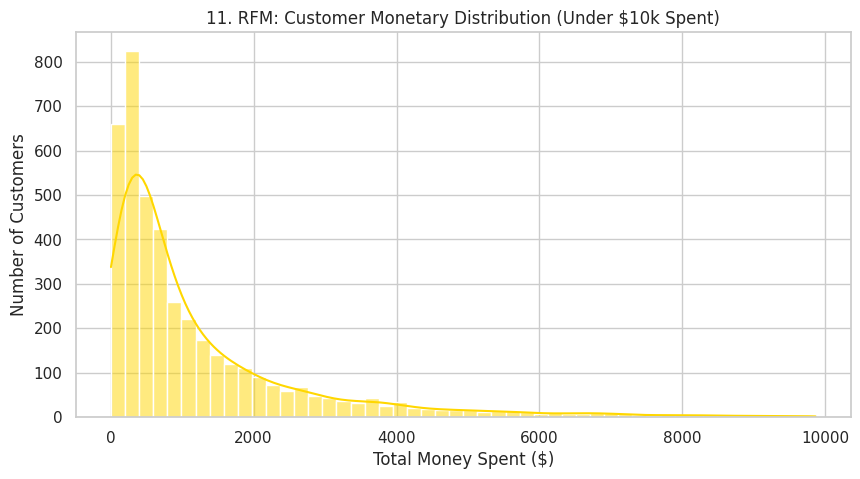

In [77]:
# 10. Histogram - Monetary Distribution (RFM)
plt.figure(figsize=(10, 5))

sns.histplot(rfm[rfm['Monetary'] < 10000]['Monetary'], bins=50, kde=True, color='gold')

plt.title('11. RFM: Customer Monetary Distribution (Under $10k Spent)')
plt.xlabel('Total Money Spent ($)')
plt.ylabel('Number of Customers')
plt.show()

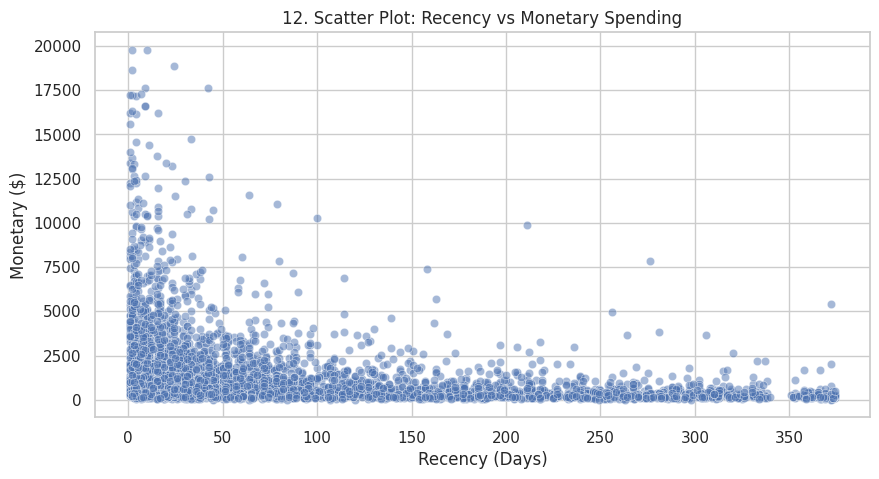

In [78]:
# 11. Scatter Plot - Recency vs Monetary
plt.figure(figsize=(10, 5))

sns.scatterplot(x='Recency', y='Monetary', data=rfm[rfm['Monetary'] < 20000], alpha=0.5)

plt.title('12. Scatter Plot: Recency vs Monetary Spending')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary ($)')
plt.show()

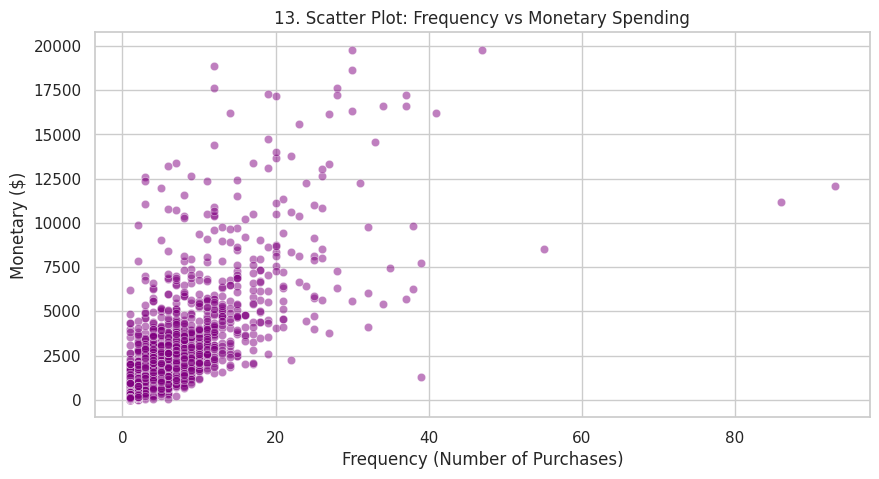

In [79]:
# 12. Scatter Plot - Frequency vs Monetary
plt.figure(figsize=(10, 5))

sns.scatterplot(x='Frequency', y='Monetary', data=rfm[(rfm['Frequency'] < 100) & (rfm['Monetary'] < 20000)], alpha=0.5, color='purple')

plt.title('13. Scatter Plot: Frequency vs Monetary Spending')
plt.xlabel('Frequency (Number of Purchases)')
plt.ylabel('Monetary ($)')
plt.show()

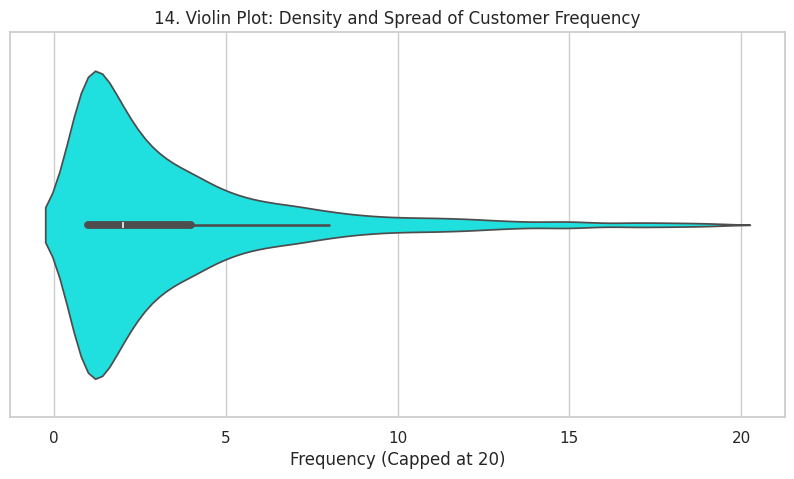

In [80]:
# 13. Violin Plot - Frequency Spread
plt.figure(figsize=(10, 5))

sns.violinplot(x=rfm[rfm['Frequency'] < 20]['Frequency'], color='cyan')

plt.title('14. Violin Plot: Density and Spread of Customer Frequency')
plt.xlabel('Frequency (Capped at 20)')
plt.show()

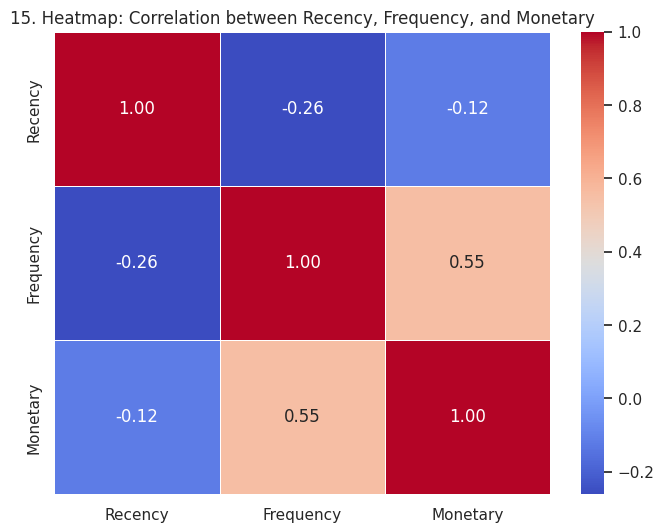

In [81]:
# 14. Heatmap - Correlation Matrix of RFM Metrics
plt.figure(figsize=(8, 6))

corr_matrix = rfm[['Recency', 'Frequency', 'Monetary']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('15. Heatmap: Correlation between Recency, Frequency, and Monetary')
plt.show()

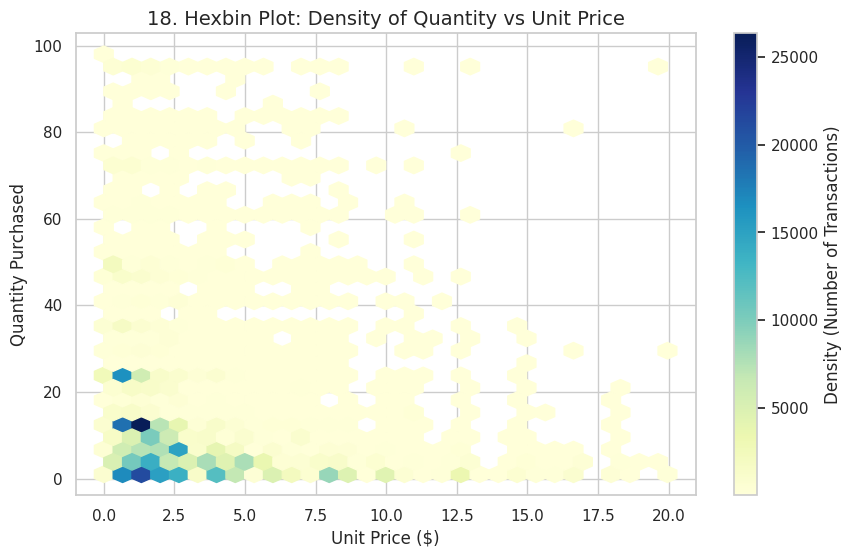

In [82]:
# 15. Hexbin Plot - Quantity vs Unit Price Density
plt.figure(figsize=(10, 6))

filtered_df = df[(df['Quantity'] > 0) & (df['Quantity'] < 100) & (df['UnitPrice'] < 20)]

plt.hexbin(x=filtered_df['UnitPrice'], y=filtered_df['Quantity'], gridsize=30, cmap='YlGnBu', mincnt=1)

cb = plt.colorbar(label='Density (Number of Transactions)')
plt.title('18. Hexbin Plot: Density of Quantity vs Unit Price', fontsize=14)
plt.xlabel('Unit Price ($)')
plt.ylabel('Quantity Purchased')
plt.show()

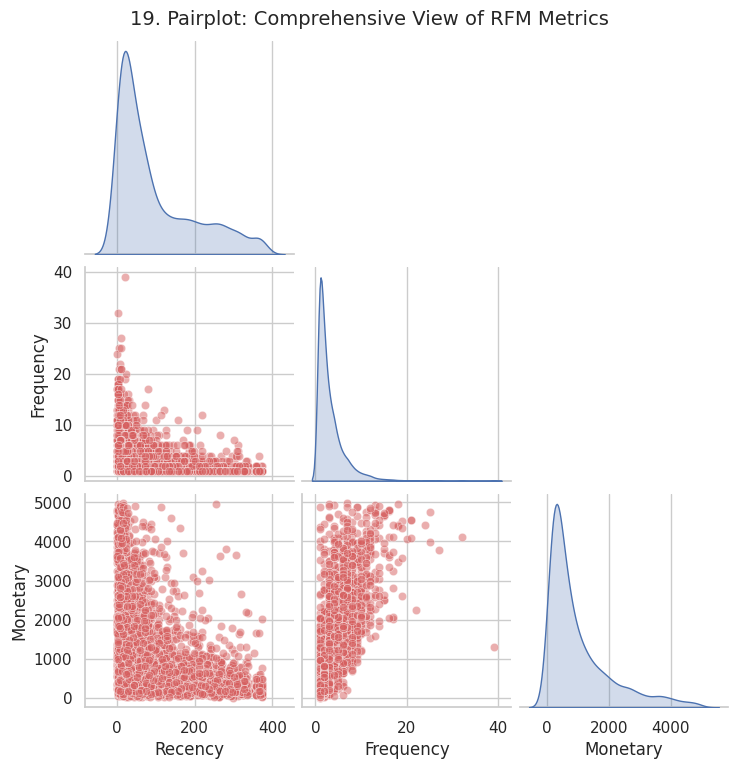

In [83]:
# 16. Pairplot - RFM Relationships
rfm_sample = rfm[(rfm['Frequency'] < 50) & (rfm['Monetary'] < 5000)]
sns.pairplot(rfm_sample[['Recency', 'Frequency', 'Monetary']], corner=True, diag_kind='kde', plot_kws={'alpha':0.5, 'color':'#D65F5F'})
plt.suptitle('19. Pairplot: Comprehensive View of RFM Metrics', y=1.02, fontsize=14)
plt.show()

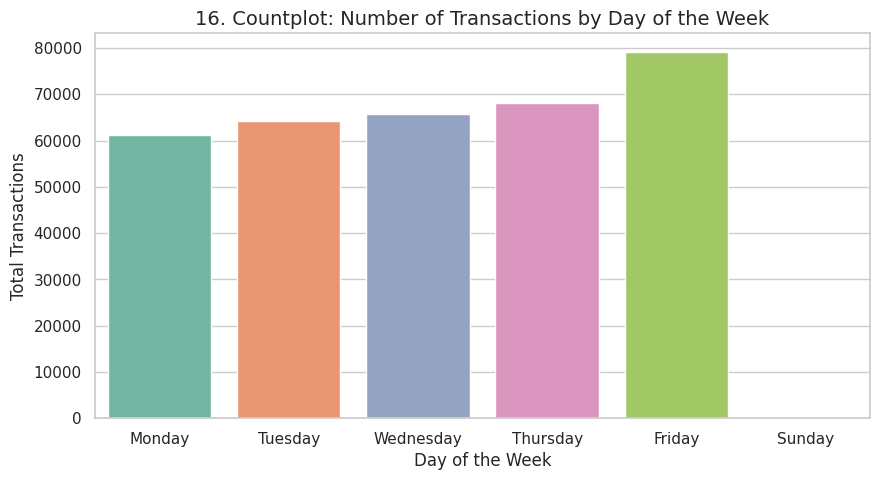

In [84]:
# 17. Countplot - Transactions by Day of the Week

plt.figure(figsize=(10, 5))
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']

sns.countplot(x='DayOfWeek', data=df, order=days_order, palette='Set2')

plt.title('16. Countplot: Number of Transactions by Day of the Week', fontsize=14)
plt.xlabel('Day of the Week')
plt.ylabel('Total Transactions')
plt.show()

In [85]:
# Standardizing the RFM values
from sklearn.preprocessing import StandardScaler
import pandas as pd

# We create the scaler
scaler = StandardScaler()

# We scale only the R, F, and M numbers
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Convert the scaled numbers back into a DataFrame so it's easy to read
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

print("Data successfully scaled!")
rfm_scaled_df.head()

Data successfully scaled!


,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.363010
1,-0.905340,0.354417,0.251699
2,-0.175360,-0.035340,-0.027988
3,-0.735345,-0.425097,-0.032406
4,2.174578,-0.425097,-0.190812


Calculating optimal clusters... 


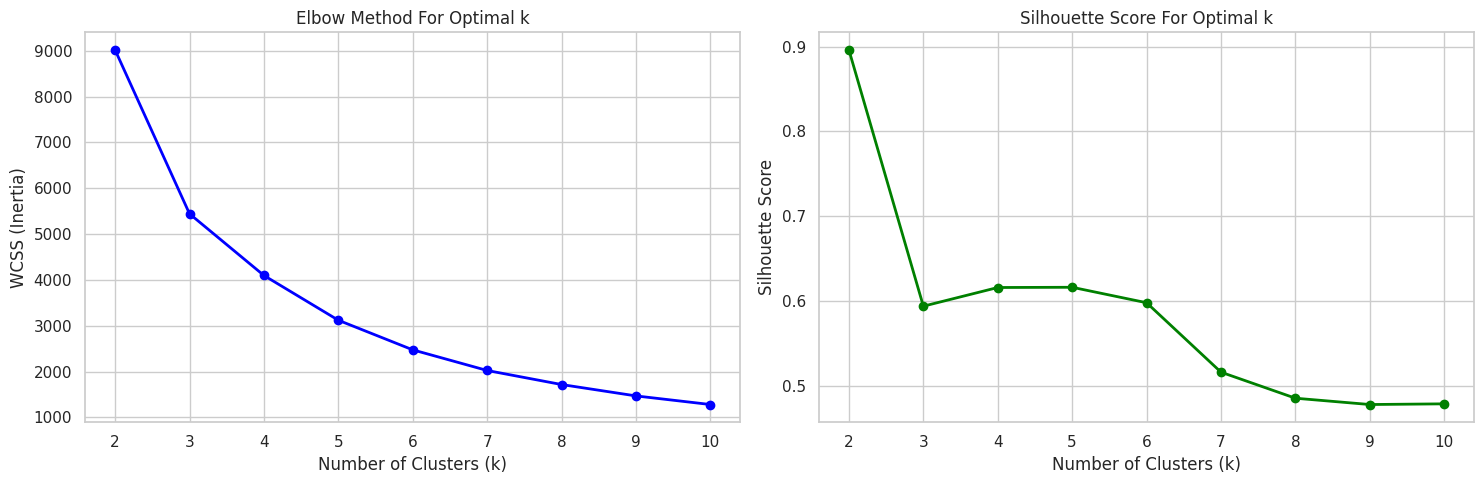

In [91]:
# Finding the optimal number of clusters
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# We will test everything from 2 clusters to 10 clusters
wcss = []
silhouette_scores = []
K_range = range(2, 11)

print("Calculating optimal clusters... ")

for k in K_range:
    # Initialize the KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)

    # Save the WCSS (Inertia) for the Elbow Curve
    wcss.append(kmeans.inertia_)

    # Save the Silhouette Score
    silhouette_scores.append(silhouette_score(rfm_scaled_df, kmeans.labels_))

# --- Plotting the Results ---
plt.figure(figsize=(15, 5))

# Graph 1: Elbow Curve
plt.subplot(1, 2, 1)
plt.plot(K_range, wcss, marker='o', color='blue', linewidth=2)
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)

# Graph 2: Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o', color='green', linewidth=2)
plt.title('Silhouette Score For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

In [92]:
# Model 1 - KMeans Clustering
from sklearn.cluster import KMeans

# 1. Train the model with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['KMeans_Cluster'] = kmeans.fit_predict(rfm_scaled_df)

# 2. Find the average spending for each cluster to label them properly
cluster_summary = rfm.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().reset_index()
sorted_clusters = cluster_summary.sort_values('Monetary', ascending=False)['KMeans_Cluster'].tolist()

# 3. Assign labels based on monetary value (highest spenders = High-Value)
def assign_label(cluster_id):
    if cluster_id == sorted_clusters[0]: return 'High-Value'
    elif cluster_id == sorted_clusters[1]: return 'Regular'
    elif cluster_id == sorted_clusters[2]: return 'Occasional'
    else: return 'At-Risk'

rfm['Segment_Label'] = rfm['KMeans_Cluster'].apply(assign_label)

print("K-Means Model Trained and Labeled successfully!")
print(rfm['Segment_Label'].value_counts())

K-Means Model Trained and Labeled successfully!
Segment_Label
Occasional    3054
At-Risk       1067
Regular        204
High-Value      13
Name: count, dtype: int64


In [93]:
# Model 2 - Agglomerative Hierarchical Clustering
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

print("Training Hierarchical Clustering... (This might take a minute)")

# Train the model
hc_model = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
rfm['HC_Cluster'] = hc_model.fit_predict(rfm_scaled_df)

# Get the score
hc_score = silhouette_score(rfm_scaled_df, rfm['HC_Cluster'])
print(f"Hierarchical Score: {hc_score:.4f}")

Training Hierarchical Clustering... (This might take a minute)
Hierarchical Score: 0.6077


In [94]:
# Model 3 - DBSCAN
from sklearn.cluster import DBSCAN

print("Training DBSCAN Clustering...")

# Train DBSCAN (eps=0.8, min_samples=10 are standard for scaled RFM)
dbscan = DBSCAN(eps=0.8, min_samples=10)
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled_df)

# Calculate score (ignoring noise points labeled as -1)
if len(set(rfm['DBSCAN_Cluster'])) > 1:
    dbscan_score = silhouette_score(rfm_scaled_df, rfm['DBSCAN_Cluster'])
else:
    dbscan_score = 0

print(f"DBSCAN Score: {dbscan_score:.4f}")

Training DBSCAN Clustering...
DBSCAN Score: 0.8545


The best model is DBSCAN with a score of 0.8545


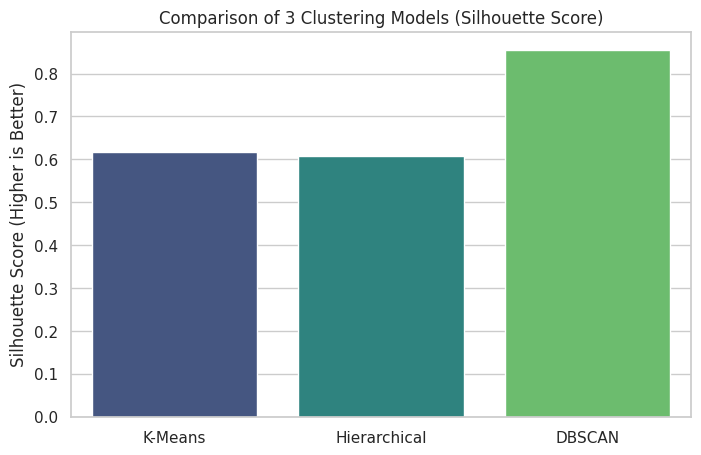

In [96]:
# Model Comparison
kmeans_score = silhouette_score(rfm_scaled_df, rfm['KMeans_Cluster'])

models = ['K-Means', 'Hierarchical', 'DBSCAN']
scores = [kmeans_score, hc_score, dbscan_score]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=scores, palette='viridis')
plt.title('Comparison of 3 Clustering Models (Silhouette Score)')
plt.ylabel('Silhouette Score (Higher is Better)')

# Determine the winner
best_idx = scores.index(max(scores))
print(f"The best model is {models[best_idx]} with a score of {scores[best_idx]:.4f}")
plt.show()

In [97]:
# Hypothesis Testing (ANOVA) for R, F, and M
import scipy.stats as stats

print("--- HYPOTHESIS TESTING (ANOVA) ---")
print("Checking if our clusters have statistically significant differences.\n")

# 1. Hypothesis Test for Recency
f_val_r, p_val_r = stats.f_oneway(
    rfm[rfm['Segment_Label']=='High-Value']['Recency'],
    rfm[rfm['Segment_Label']=='Regular']['Recency'],
    rfm[rfm['Segment_Label']=='Occasional']['Recency'],
    rfm[rfm['Segment_Label']=='At-Risk']['Recency']
)
print(f"1. Recency P-Value:   {p_val_r} (Statistically Significant? {'Yes' if p_val_r < 0.05 else 'No'})")

# 2. Hypothesis Test for Frequency
f_val_f, p_val_f = stats.f_oneway(
    rfm[rfm['Segment_Label']=='High-Value']['Frequency'],
    rfm[rfm['Segment_Label']=='Regular']['Frequency'],
    rfm[rfm['Segment_Label']=='Occasional']['Frequency'],
    rfm[rfm['Segment_Label']=='At-Risk']['Frequency']
)
print(f"2. Frequency P-Value: {p_val_f} (Statistically Significant? {'Yes' if p_val_f < 0.05 else 'No'})")

# 3. Hypothesis Test for Monetary
f_val_m, p_val_m = stats.f_oneway(
    rfm[rfm['Segment_Label']=='High-Value']['Monetary'],
    rfm[rfm['Segment_Label']=='Regular']['Monetary'],
    rfm[rfm['Segment_Label']=='Occasional']['Monetary'],
    rfm[rfm['Segment_Label']=='At-Risk']['Monetary']
)
print(f"3. Monetary P-Value:  {p_val_m} (Statistically Significant? {'Yes' if p_val_m < 0.05 else 'No'})")

--- HYPOTHESIS TESTING (ANOVA) ---
Checking if our clusters have statistically significant differences.

1. Recency P-Value:   0.0 (Statistically Significant? Yes)
2. Frequency P-Value: 0.0 (Statistically Significant? Yes)
3. Monetary P-Value:  0.0 (Statistically Significant? Yes)


In [98]:
# Recommendation System (Cosine Similarity)
from sklearn.metrics.pairwise import cosine_similarity

print("Building Recommendation Matrix... (Filtering rare items for memory efficiency)")

# Step 1: Keep only the top 1000 most popular items so Colab's memory doesn't crash
top_items = df['Description'].value_counts().head(1000).index
reco_df = df[df['Description'].isin(top_items)]

# Step 2: Create a CustomerID-Description matrix
customer_item_matrix = reco_df.pivot_table(index='CustomerID', columns='Description', values='Quantity', aggfunc='sum')
customer_item_matrix = customer_item_matrix.fillna(0)
# Convert to 1s and 0s (Purchased or Not Purchased)
customer_item_matrix = customer_item_matrix.applymap(lambda x: 1 if x > 0 else 0)

# Step 3: Compute Item-Based Cosine Similarity
item_item_matrix = cosine_similarity(customer_item_matrix.T)
item_similarity_df = pd.DataFrame(item_item_matrix, index=customer_item_matrix.columns, columns=customer_item_matrix.columns)

print("Recommendation Engine Ready!")

# Test it
test_product = item_similarity_df.columns[0]
recommendations = item_similarity_df[test_product].sort_values(ascending=False)[1:6].index.tolist()
print(f"\nIf a customer buys '{test_product}', we recommend:")
for i, item in enumerate(recommendations, 1):
    print(f"{i}. {item}")

Building Recommendation Matrix... (Filtering rare items for memory efficiency)
Recommendation Engine Ready!

If a customer buys ' DOLLY GIRL BEAKER', we recommend:
1. SPACEBOY BEAKER
2. DOLLY GIRL LUNCH BOX
3. SPACEBOY LUNCH BOX 
4. DOLLY GIRL CHILDRENS CUP
5. DOLLY GIRL CHILDRENS BOWL


In [103]:
# Save files for Streamlit
import joblib

joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Save the similarity matrix as a CSV so Streamlit can read it
item_similarity_df.to_csv('item_similarity.csv')

print("Models and Matrix saved successfully for Streamlit!")

Models and Matrix saved successfully for Streamlit!


In [104]:
# Creating the Streamlit App File
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import numpy as np

# Load Models
kmeans = joblib.load('kmeans_model.pkl')
scaler = joblib.load('scaler.pkl')
item_similarity_df = pd.read_csv('item_similarity.csv', index_col=0)

st.title("🛒 Shopper Spectrum Dashboard")
st.sidebar.title("Navigation")
menu = st.sidebar.radio("Go to", ["Product Recommendation", "Customer Segmentation"])

if menu == "Product Recommendation":
    st.header("Product Recommender")
    product_list = item_similarity_df.columns.tolist()
    product_name = st.selectbox("Select or Enter a Product Name", product_list)

    if st.button("Recommend"):
        recommendations = item_similarity_df[product_name].sort_values(ascending=False)[1:6].index.tolist()
        st.subheader("Recommended Products:")
        for item in recommendations:
            st.write(f"- {item}")

elif menu == "Customer Segmentation":
    st.header("Customer Segmentation Module")
    recency = st.number_input("Recency (days since last purchase)", min_value=0, value=10)
    frequency = st.number_input("Frequency (number of purchases)", min_value=0, value=5)
    monetary = st.number_input("Monetary (total spend)", min_value=0.0, value=500.0)

    if st.button("Predict Segment"):
        # Scale the inputs
        input_scaled = scaler.transform([[recency, frequency, monetary]])
        # Predict
        cluster = kmeans.predict(input_scaled)[0]

        # Map cluster to label (based on our earlier logic)
        labels = {0: "High-Value", 1: "Regular", 2: "Occasional", 3: "At-Risk"}
        st.success(f"This customer belongs to: **{labels.get(cluster, 'Unknown')} Shopper**")

Overwriting app.py


In [110]:
# Final App Launch
import urllib.request

password = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n")
print("\n" + "="*50)
print(f"Your Password / Endpoint IP is: {password}")
print("="*50)
print("\nClick the blue link below that ends in 'loca.lt' to view your website!")

!streamlit run app.py --server.enableCORS false --server.enableXsrfProtection false & npx localtunnel --port 8501


Your Password / Endpoint IP is: 35.252.72.187

Click the blue link below that ends in 'loca.lt' to view your website!


⠙⠹your url is: https://blue-spies-happen.loca.lt
2026-06-21 20:02:51.112 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.252.72.187:8501

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
  Stopping...
^C
